In [31]:
import h5py
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
import torch

from robustness.audio_functions.jsinV3DataLoader_precombined import *
import lightning_scripts.jsinV3DataLoader_precombined_batched as batched_loading
from robustness.audio_functions.audio_transforms import *

In [32]:
source_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/jsinV3BalancedProcessed/sr_20000/splits/valid_stackedDataframeHDF_n150_VJRUH4IEPDGPNH2JZMULSQKOWYNQ6KMM.pdh5'
noise_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/audioset_dataframes/sr20000/sr20000_balanced_train_segments_raw_exclude_speech_and_only_music.pdh5' 
dataframe_metadata = pd.read_hdf(source_h5)
source_files = h5py.File(source_h5, 'r')

noise_metadata = pd.read_hdf(noise_h5)
noise_files = h5py.File(noise_h5, 'r')

In [4]:
dataframe_metadata

,_path_only,_pre_sliced_segment_index,_pre_split_index,_query_str,_shape_flat,_signal_segment_len,corpus,corpus_count,duration_ms_parent_signal,duration_ms_word,...,word_ms_query_str,word_utterances_per_speaker,zeros_count_parent_signal,zeros_duration_ms,zeros_ratio,corpus_int,path_int,source_int,speaker_int,word_int
0,/home/raygon/scratch/swc/hdf5/sr20000/Elizabet...,70259.0,264765.0,?start_ms=1592040&end_ms=1592300,146757504.0,45200.0,swc,2.0,3.209198e+06,260.0,...,?start_ms=1592040&end_ms=1592300,1283.0,2589008,58707.664399,0.017641,1,89318,116291,303,111
1,/home/raygon/scratch/swc/hdf5/sr20000/Bintulu.h5,255816.0,274336.0,?start_ms=410210&end_ms=410670,114001024.0,49200.0,swc,2.0,1.292529e+06,460.0,...,?start_ms=410210&end_ms=410670,493.0,148124,3358.820862,0.001299,1,40581,67554,346,369
2,/home/raygon/scratch/swc/hdf5/sr20000/Civiliza...,200468.0,244246.0,?start_ms=541590&end_ms=541880,45077824.0,45800.0,swc,2.0,1.022173e+06,290.0,...,?start_ms=541590&end_ms=541880,316.0,73368,1663.673469,0.001628,1,60581,87554,263,13
3,/home/raygon/scratch/swc/hdf5/sr20000/Schr%c3%...,156769.0,318849.0,?start_ms=1138260&end_ms=1138780,50566848.0,50400.0,swc,2.0,1.146641e+06,520.0,...,?start_ms=1138260&end_ms=1138780,315.0,78923,1789.637188,0.001561,1,260492,287465,372,541
4,/home/raygon/scratch/swc/hdf5/sr20000/Justin_T...,410877.0,258821.0,?start_ms=1221180&end_ms=1221580,91259072.0,48000.0,swc,2.0,2.069367e+06,400.0,...,?start_ms=1221180&end_ms=1221580,5557.0,677987,15373.854875,0.007429,1,174114,201087,413,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40646,/home/raygon/scratch/swc/hdf5/sr20000/Minecraf...,40481.0,233252.0,?start_ms=505220&end_ms=505680,63509184.0,49200.0,swc,2.0,1.440118e+06,460.0,...,?start_ms=505220&end_ms=505680,18533.0,758984,17210.521542,0.011951,1,199825,226798,313,511
40647,/home/raygon/scratch/swc/hdf5/sr20000/Harvey_M...,63276.0,234879.0,?start_ms=3375550&end_ms=3376010,344527232.0,49200.0,swc,2.0,3.906204e+06,460.0,...,?start_ms=3375550&end_ms=3376010,5342.0,4502945,102107.596372,0.01307,1,130962,157935,259,521
40648,/home/raygon/projects/user/jfeather/jsinDatase...,105922.0,412356.0,?,163600.0,45800.0,wsj,1.0,1.022500e+04,290.0,...,?start_ms=8160&end_ms=8450,489.0,891,55.6875,0.005446,2,365126,26626,151,360
40649,/home/raygon/scratch/swc/hdf5/sr20000/Munich.h5,62392.0,184478.0,?start_ms=225810&end_ms=226450,201791168.0,52800.0,swc,2.0,4.575764e+06,640.0,...,?start_ms=225810&end_ms=226450,1791.0,1192902,27049.931973,0.005912,1,206306,233279,323,704


In [61]:
dataframe_metadata['duration_ms_word'][0]

260.0

In [5]:
noise_metadata

,YTID,_pre_map_index,channel_num,corpus,data_split,end_YT_clip_secs,end_secs,has_music_label,index_np_file_before_exclusions,labels,...,source,sr,start_YT_clip_secs,start_secs,youtube_source,labels_int,corpus_int,labels_decoded_slugged,_index_before_label_removal,_pre_subset_index
0,eqUNT2lvvCQ,0.0,1.0,AUDIOSET,balanced_train_segments,20.0,10.005333,False,0.0,"/m/03cczk,/m/07pdhp0,/t/dd00125",...,YT_eqUNT2lvvCQ.wav,20000,10.0,0.0,http://youtu.be/eqUNT2lvvCQ?start=10&end=20,"145,264,508",0,"chewing-mastication,biting,inside-small-room",0,0
1,Z0OTDXtjK9M,1.0,0.0,AUDIOSET,balanced_train_segments,220.0,10.007800,True,1.0,"/m/02rr_,/m/0342h,/m/04szw,/m/07m2kt,/m/0fx80y",...,YT_Z0OTDXtjK9M.wav,20000,210.0,0.0,http://youtu.be/Z0OTDXtjK9M?start=210&end=220,"125,140,189,251,433",0,"effects-unit,guitar,musical-instrument,chorus-...",1,1
2,cTIpuY69fnk,2.0,0.0,AUDIOSET,balanced_train_segments,300.0,10.026667,True,2.0,/m/07szfh9,...,YT_cTIpuY69fnk.wav,20000,290.0,0.0,http://youtu.be/cTIpuY69fnk?start=290&end=300,377,0,cacophony,2,2
3,7Msk_hkz6zk,3.0,1.0,AUDIOSET,balanced_train_segments,40.0,10.007800,True,3.0,"/m/0155w,/m/06j6l,/m/06rqw",...,YT_7Msk_hkz6zk.wav,20000,30.0,0.0,http://youtu.be/7Msk_hkz6zk?start=30&end=40,"14,225,229",0,"blues,rhythm-and-blues,ska",3,3
4,8oBmYWGuVF0,4.0,0.0,AUDIOSET,balanced_train_segments,40.0,10.031020,False,4.0,/m/07plct2,...,YT_8oBmYWGuVF0.wav,20000,30.0,0.0,http://youtu.be/8oBmYWGuVF0?start=30&end=40,273,0,crushing,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15957,r0I-G70gyo0,15999.0,0.0,AUDIOSET,balanced_train_segments,40.0,10.026667,False,21742.0,"/m/0192l,/m/085jw",...,YT_r0I-G70gyo0.wav,20000,30.0,0.0,http://youtu.be/r0I-G70gyo0?start=30&end=40,"26,384",0,"bagpipes,wind-instrument-woodwind-instrument",15999,15999
15958,BIX92PE-Zj0,16000.0,0.0,AUDIOSET,balanced_train_segments,40.0,10.031020,True,21744.0,"/m/01x3z,/m/07qjznl",...,YT_BIX92PE-Zj0.wav,20000,30.0,0.0,http://youtu.be/BIX92PE-Zj0?start=30&end=40,"69,306",0,"clock,tick-tock",16000,16000
15959,mH2y5B7aTWo,16001.0,1.0,AUDIOSET,balanced_train_segments,550.0,10.007800,False,21746.0,/m/078jl,...,YT_mH2y5B7aTWo.wav,20000,540.0,0.0,http://youtu.be/mH2y5B7aTWo?start=540&end=550,236,0,snake,16001,16001
15960,M5OCCuCIMbA,16002.0,1.0,AUDIOSET,balanced_train_segments,140.0,10.005333,False,21747.0,/m/032n05,...,YT_M5OCCuCIMbA.wav,20000,130.0,0.0,http://youtu.be/M5OCCuCIMbA?start=130&end=140,138,0,whale-vocalization,16002,16002


In [57]:
signal_0 = source_files['ndarray_data']['signal'][0:2]
noise_0 = noise_files['ndarray_data']['signal'][1]

In [60]:
signal_0[1].shape

(49200,)

(49200,)


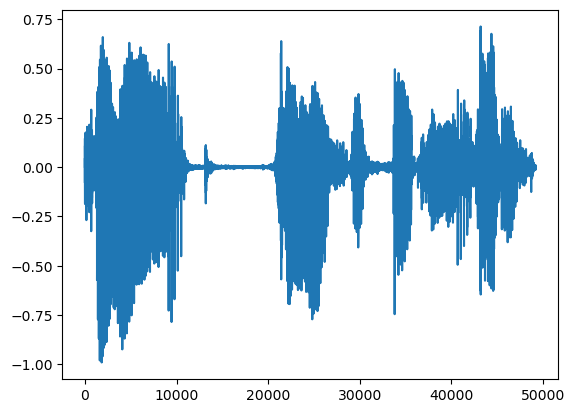

In [11]:
print(signal_0.shape)
plt.plot(signal_0)
Audio(signal_0, rate=20000)

(200157,)


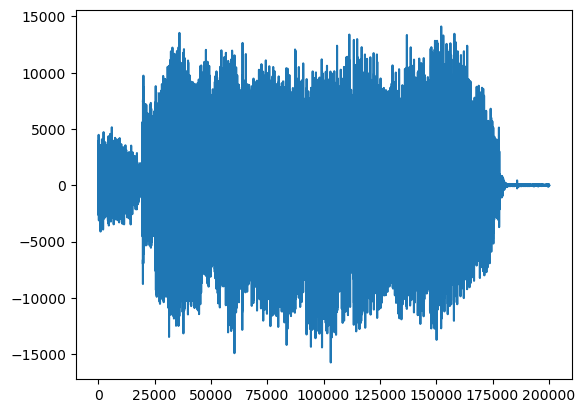

In [ ]:
print(noise_0.shape)
plt.plot(noise_0)
Audio(noise_0, rate=20000)

In [49]:
from robustness.audio_functions.audio_transforms import CombineWithRandomDBSNR

class RandomCrop:
    def __init__(self, crop_length):
        self.crop_length = crop_length

    def __call__(self, x):
        start_idx = np.random.randint(x.shape[0] - self.crop_length)
        return x[start_idx:start_idx+self.crop_length]

class SpeechInNoiseDataset(torch.utils.data.Dataset):
    def __init__(
            self,
            speech_h5_path,
            noise_h5_path,
            chunk_size=1,
            transform=None,
            low_db=-10,
            high_db=10,
    ):
        super().__init__()
        self.speech_files = h5py.File(speech_h5_path, 'r')
        self.noise_files = h5py.File(noise_h5_path, 'r')
        self.speech_metadata = pd.read_hdf(speech_h5_path)
        self.noise_metadata = pd.read_hdf(noise_h5_path)

        self.num_noise_files = len(self.noise_metadata)
        self.chunk_size = chunk_size

        self.random_crop = RandomCrop(40000)
        self.combiner = CombineWithRandomDBSNR(low_db, high_db)
    
    def __len__(self):
        return len(self.speech_metadata) // self.chunk_size
    
    def __getitem__(self, idx):
        speech = self.speech_files['ndarray_data']['signal'][idx + self.chunk_size - 1]
        noise_idx = np.random.randint(self.num_noise_files - self.chunk_size)
        noise = self.noise_files['ndarray_data']['signal'][noise_idx + self.chunk_size - 1]

        # randomly crop clips to be the same length (2 seconds = 40000 samples)
        speech = self.random_crop(speech)
        noise = self.random_crop(noise)

        # randomly mix the speech and noise
        combined, _ = self.combiner(torch.tensor(speech), torch.tensor(noise))

        return combined

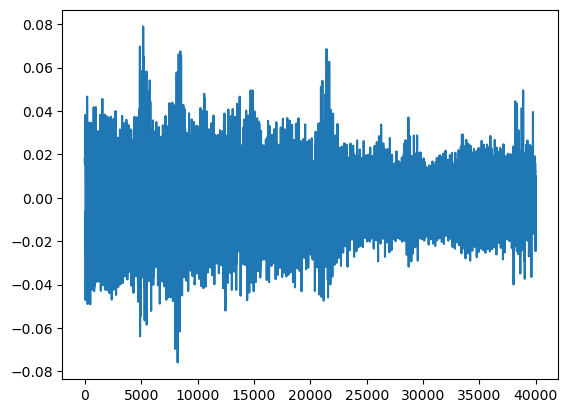

In [119]:
dataset = SpeechInNoiseDataset(source_h5, noise_h5)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(dataloader))
batch_np = batch.numpy()
batch_index = 2

plt.plot(batch_np[batch_index])
Audio(batch_np[batch_index], rate=20000)

In [171]:
class MatchedRandomSignalCrops:
    def __init__(self, crop_length=40000):
        self.crop_length = crop_length

    def __call__(self, signal_1, signal_2, word_length_1, word_length_2):
        start_idx_2 = 1e10
        while start_idx_2 + self.crop_length > signal_2.shape[0]:
            start_idx_1 = np.random.randint(signal_1.shape[0] - self.crop_length)
            cropped_1 = signal_1[start_idx_1:start_idx_1+self.crop_length]

            # compute the position of the start of the word in the cropped signal
            word_start_1_original = (len(signal_1) - word_length_1) // 2
            word_start_1_cropped = word_start_1_original - start_idx_1

            # crop second signal so that the word is in the same start position
            #word_start_2_original = (len(signal_2) - word_length_2) // 2
            #start_idx_2 =  word_start_2_original - word_start_1_cropped
            start_idx_2 = start_idx_1 + (len(signal_2) - len(signal_1))


        print(len(signal_1), len(signal_2))
        print(start_idx_1, start_idx_2)
        cropped_2 = signal_2[start_idx_2:start_idx_2+self.crop_length]

        return cropped_1, cropped_2

class CombineWithRandomDBSNRWithParam(torch.nn.Module):
    """
    Takes two signals and combines them at a specified dB SNR level.
    
    Args: 
        low_snr (float): the low end for the range of dB SNR to draw from
        high_snr (float): the high end for the range of db SNR to draw from
        rms_level (float): the end RMS value for the combined sound

    Returns:
        signal_in_noise, None 

    """
    def __init__(self, low_snr=-10, high_snr=10):
        self.low_snr=low_snr
        self.high_snr=high_snr
        super(CombineWithRandomDBSNRWithParam, self).__init__()

    def forward(self, foreground_wav, background_wav):
        """
        Args:  
            foreground_wav (torch.Tensor): the waveform that will be used as
                the foreground audio sample (usually speech)
            background_wav (torch.Tensor): the waveform that will be used as 
                the background audio sample
        """
        rand_db_snr = self.low_snr + (self.high_snr - self.low_snr) * torch.rand(1)
        rms_ratio = np.power(10.0, rand_db_snr / 20.0)
        # Demean signal and noise before computing rms
        if foreground_wav is not None:
            foreground_wav = ch_demean(foreground_wav)
            rms_foreground = ch_rms(foreground_wav)
        else:
            rms_foreground = 0
            foreground_wav = torch.zeros(background_wav.shape)
        if background_wav is not None:
            background_wav = ch_demean(background_wav)
            rms_background = ch_rms(background_wav)
        else:
            rms_background = 0
            background_wav = torch.zeros(foreground_wav.shape)

        # Calculate the scale factor for the two sounds
        # For now, to align with the jsinv3 dataset, we include the infinite SNR 
        # cases
        if rms_foreground == 0: # No foreground condition (just noise)
            noise_scale_factor = 1
        elif rms_background == 0: 
            noise_scale_factor = 0
        else:
            noise_scale_factor = torch.div(rms_foreground, 
                                           torch.mul(rms_background,
                                                     rms_ratio))
 
        background_wav = torch.mul(noise_scale_factor, background_wav)
        signal_in_noise = torch.add(foreground_wav, background_wav)

        return signal_in_noise, rand_db_snr

class CombineWithFixedDBSNR(torch.nn.Module):
    """
    Takes two signals and combines them at a specified dB SNR level.
    
    Returns:
        signal_in_noise, None 

    """
    def __init__(self):
        super(CombineWithFixedDBSNR, self).__init__()

    def forward(self, foreground_wav, background_wav, rand_db_snr):
        """
        Args:  
            foreground_wav (torch.Tensor): the waveform that will be used as
                the foreground audio sample (usually speech)
            background_wav (torch.Tensor): the waveform that will be used as 
                the background audio sample
        """
        rms_ratio = np.power(10.0, rand_db_snr / 20.0)
        # Demean signal and noise before computing rms
        if foreground_wav is not None:
            foreground_wav = ch_demean(foreground_wav)
            rms_foreground = ch_rms(foreground_wav)
        else:
            rms_foreground = 0
            foreground_wav = torch.zeros(background_wav.shape)
        if background_wav is not None:
            background_wav = ch_demean(background_wav)
            rms_background = ch_rms(background_wav)
        else:
            rms_background = 0
            background_wav = torch.zeros(foreground_wav.shape)

        # Calculate the scale factor for the two sounds
        # For now, to align with the jsinv3 dataset, we include the infinite SNR 
        # cases
        if rms_foreground == 0: # No foreground condition (just noise)
            noise_scale_factor = 1
        elif rms_background == 0: 
            noise_scale_factor = 0
        else:
            noise_scale_factor = torch.div(rms_foreground, 
                                           torch.mul(rms_background,
                                                     rms_ratio))
 
        background_wav = torch.mul(noise_scale_factor, background_wav)
        signal_in_noise = torch.add(foreground_wav, background_wav)

        return signal_in_noise

class MatchedCombineWithRandomDBSNR: 
    def __init__(self, low_db=-10, high_db=10):
        self.low_db = low_db
        self.high_db = high_db
        self.combiner_random = CombineWithRandomDBSNRWithParam(low_db, high_db)
        self.combiner_fixed = CombineWithFixedDBSNR()
    
    def __call__(self, foreground_wav1, foreground_wav2, background_wav1, background_wav2):
        combined_1, rand_db_snr = self.combiner_random(foreground_wav1, background_wav1)
        combined_2 =  self.combiner_fixed(foreground_wav2, background_wav2, rand_db_snr)

        return combined_1, combined_2

In [172]:
class MatchedSpeechInNoiseDataset(torch.utils.data.Dataset):
    def __init__(
            self,
            speech_h5_path,
            noise_h5_path,
            chunk_size=2,
            transform=None,
            low_db=-10,
            high_db=10,
    ):
        super().__init__()
        self.speech_files = h5py.File(speech_h5_path, 'r')
        self.noise_files = h5py.File(noise_h5_path, 'r')
        self.speech_metadata = pd.read_hdf(speech_h5_path)
        self.noise_metadata = pd.read_hdf(noise_h5_path)

        self.num_noise_files = len(self.noise_metadata)
        self.chunk_size = chunk_size

        self.random_crop = RandomCrop(40000)
        self.matched_random_crop = MatchedRandomSignalCrops()
        self.matched_combiner = MatchedCombineWithRandomDBSNR(low_db, high_db)
    
    def __len__(self):
        return len(self.speech_metadata) // self.chunk_size
    
    def __getitem__(self, idx):
        speech = self.speech_files['ndarray_data']['signal'][idx:idx + self.chunk_size]
        noise_idx = np.random.randint(self.num_noise_files - self.chunk_size)
        noise = self.noise_files['ndarray_data']['signal'][noise_idx:noise_idx + self.chunk_size]

        speech_1, speech_2 = speech[0], speech[1]
        noise_1, noise_2 = self.random_crop(noise[0]), self.random_crop(noise[1])
        noise_1, noise_2 = torch.tensor(noise_1), torch.tensor(noise_2)

        length_word_1 = int(self.speech_metadata['duration_ms_word'][idx] * 20)
        length_word_2 = int(self.speech_metadata['duration_ms_word'][idx + 1] * 20)

        # randomly crop clips to be the same length (2 seconds = 40000 samples)
        cropped_11, cropped_21 = self.matched_random_crop(speech_1, speech_2, length_word_1, length_word_2)
        cropped_12, cropped_22 = self.matched_random_crop(speech_1, speech_2, length_word_1, length_word_2)

        cropped_11, cropped_21 = torch.tensor(cropped_11), torch.tensor(cropped_21)
        cropped_12, cropped_22 = torch.tensor(cropped_12), torch.tensor(cropped_22)

        # randomly mix the speech and noise with the same DBSNR
        combined_11, combined_22 = self.matched_combiner(cropped_11, cropped_21, noise_1, noise_2)
        combined_12, combined_21 = self.matched_combiner(cropped_12, cropped_22, noise_2, noise_1)  

        return combined_11, combined_21, combined_12, combined_22

In [181]:
dataset = MatchedSpeechInNoiseDataset(source_h5, noise_h5)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

combined_11, combined_21, combined_12, combined_22 = next(iter(dataloader))
combined_11, combined_21, combined_12, combined_22 = combined_11.numpy(), combined_21.numpy(), combined_12.numpy(), combined_22.numpy()

45400 51800
4983 11383
45400 51800
3471 9871
50200 50400
5537 5737
50200 50400
9121 9321
47800 54800
6692 13692
47800 54800
1935 8935
47000 45000
4317 2317
47000 45000
3917 1917


In [182]:
batch_index = 0
Audio(combined_11[batch_index], rate=20000)

In [187]:
Audio(combined_12[batch_index], rate=20000)

In [184]:
Audio(combined_21[batch_index], rate=20000)

In [185]:
Audio(combined_22[batch_index], rate=20000)

## Testing Module Version

In [1]:
import h5py
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
import torch

from robustness.audio_functions.jsinV3DataLoader_precombined import MatchedSpeechInNoiseDataset
from robustness.audio_functions.audio_transforms import *

In [2]:
source_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/jsinV3BalancedProcessed/sr_20000/splits/valid_stackedDataframeHDF_n150_VJRUH4IEPDGPNH2JZMULSQKOWYNQ6KMM.pdh5'
noise_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/audioset_dataframes/sr20000/sr20000_balanced_train_segments_raw_exclude_speech_and_only_music.pdh5' 

dataset = MatchedSpeechInNoiseDataset(source_h5, noise_h5)

In [3]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

combined_11, combined_12, combined_21, combined_22 = next(iter(dataloader))
combined_11, combined_12, combined_21, combined_22 = combined_11.numpy(), combined_12.numpy(), combined_21.numpy(), combined_22.numpy()

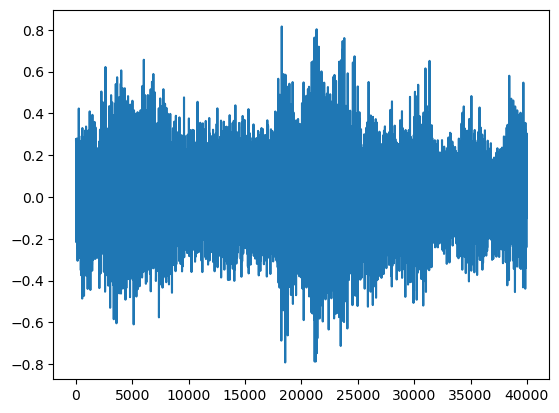

In [4]:
batch_index = 0
plt.plot(combined_11[batch_index])
Audio(combined_11[batch_index], rate=20000)

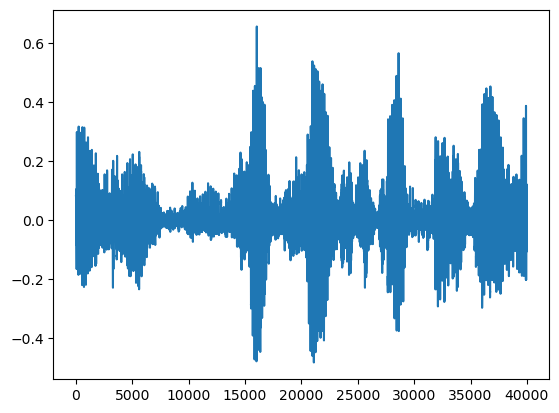

In [5]:
plt.plot(combined_12[batch_index])
Audio(combined_12[batch_index], rate=20000)

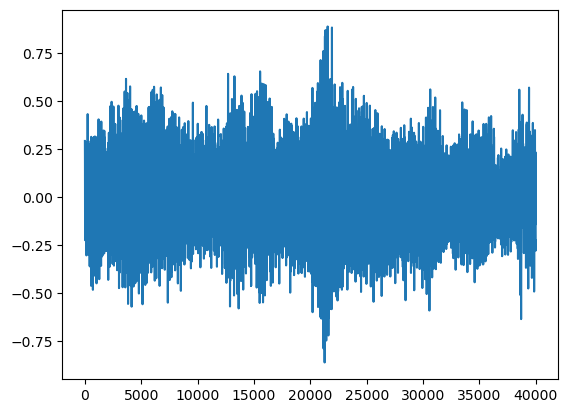

In [6]:
plt.plot(combined_21[batch_index])
Audio(combined_21[batch_index], rate=20000)

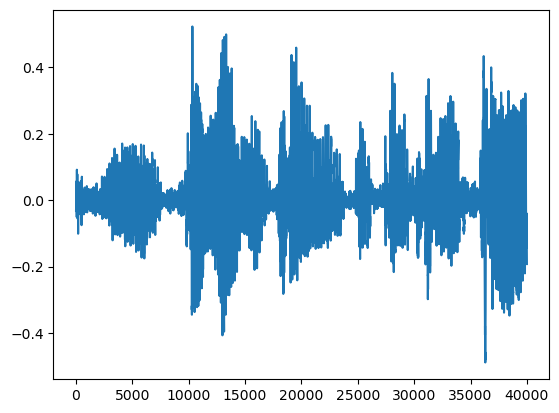

In [8]:
plt.plot(combined_22[batch_index])
Audio(combined_22[batch_index], rate=20000)

In [9]:
from robustness.audio_functions.audio_transforms import MatchedRandomSignalCrops
import numpy as np
import torch
import matplotlib.pyplot as plt

In [10]:
test_1 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
test_2 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])


test_1, test_2 = torch.tensor(test_1), torch.tensor(test_2)

matched_cropper = MatchedRandomSignalCrops(crop_length=6)
cropped_1, cropped_2 = matched_cropper(test_2, test_1)

print(cropped_1)
print(cropped_2)


tensor([2, 3, 4, 5, 6, 7])
tensor([3, 4, 5, 6, 7, 8])


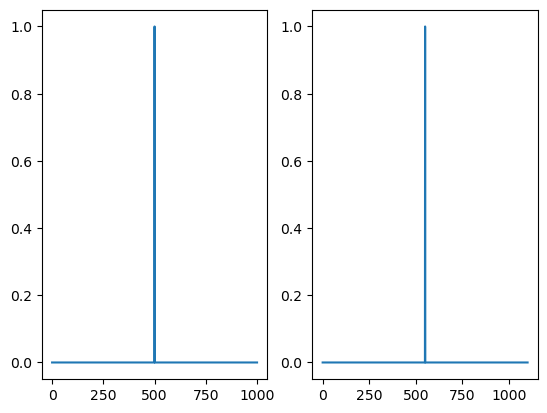

In [11]:
input_1 = torch.zeros(1001)
input_2 = torch.zeros(1101)

input_1[500] = 1
input_2[550] = 1

fig, axs = plt.subplots(1, 2)
axs[0].plot(input_1)
axs[1].plot(input_2)
random_cropper  = MatchedRandomSignalCrops(crop_length=600)
out_1, out_2 = random_cropper(input_1, input_2)

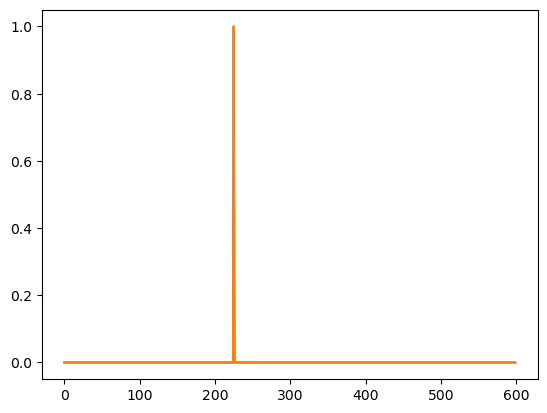

In [12]:
plt.plot(out_1, label='out_1')
plt.plot(out_2, label='out_2')

## Developing the Chunked Version

In [33]:
class MatchedSpeechInNoiseDatasetBatched(torch.utils.data.Dataset):
    def __init__(
            self,
            speech_h5_path,
            noise_h5_path,
            low_db=-10,
            high_db=10,
            batch_size=1,
            transform=None,
    ):
        super().__init__()
        self.speech_files = h5py.File(speech_h5_path, 'r')
        self.noise_files = h5py.File(noise_h5_path, 'r')
        self.speech_metadata = pd.read_hdf(speech_h5_path)
        self.noise_metadata = pd.read_hdf(noise_h5_path)

        self.num_noise_files = len(self.noise_metadata)
        self.batch_size = batch_size

        self.random_crop = audio_transforms.RandomCrop(40000)
        self.matched_random_crop = audio_transforms.MatchedRandomSignalCrops(40000)
        self.matched_combiner = audio_transforms.MatchedCombineWithRandomDBSNR(low_db, high_db)
    
    def __len__(self):
        return len(self.speech_metadata) // (2 * self.batch_size)
    
    def __getitem__(self, idx):
        speech = self.speech_files['ndarray_data']['signal'][idx:idx + self.batch_size * 2]
        noise_idx = np.random.randint(self.num_noise_files - self.batch_size * 2)
        noise = self.noise_files['ndarray_data']['signal'][noise_idx:noise_idx + self.batch_size * 2]
        
        # shuffle the indices of speech and noise
        speech = speech[np.random.permutation(speech.shape[0])]
        noise = noise[np.random.permutation(noise.shape[0])]
        
        output_11, output_12, output_21, output_22 = [], [], [], []
        for i in range(self.batch_size):
            speech_1, speech_2 = speech[i * 2], speech[i * 2 + 1]
            if len(speech_1) > len(speech_2):
                speech_1, speech_2 = speech_2, speech_1
            noise_1, noise_2 = self.random_crop(noise[0]), self.random_crop(noise[1])
            noise_1, noise_2 = torch.tensor(noise_1), torch.tensor(noise_2)

            # randomly crop clips to be the same length (2 seconds = 40000 samples)
            cropped_11, cropped_21 = self.matched_random_crop(speech_1, speech_2)
            cropped_12, cropped_22 = self.matched_random_crop(speech_1, speech_2)

            cropped_11, cropped_21 = torch.tensor(cropped_11), torch.tensor(cropped_21)
            cropped_12, cropped_22 = torch.tensor(cropped_12), torch.tensor(cropped_22)

            # randomly mix the speech and noise with the same DBSNR
            combined_11, combined_21 = self.matched_combiner(cropped_11, cropped_21, noise_1, noise_1)
            combined_12, combined_22 = self.matched_combiner(cropped_12, cropped_22, noise_2, noise_2)  

            output_11.append(combined_11)
            output_12.append(combined_12)
            output_21.append(combined_21)
            output_22.append(combined_22)
        
        output_11 = torch.stack(output_11)
        output_12 = torch.stack(output_12)
        output_21 = torch.stack(output_21)
        output_22 = torch.stack(output_22)

        return output_11, output_12, output_21, output_22

In [39]:
dataset = MatchedSpeechInNoiseDatasetBatched(source_h5, noise_h5, batch_size=5)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

In [40]:
output_11, output_12, output_21, output_22 = next(iter(dataloader))
output_11, output_12, output_21, output_22 = output_11.squeeze().numpy(), output_12.squeeze().numpy(), output_21.squeeze().numpy(), output_22.squeeze().numpy()

In [46]:
batch_index = 1
Audio(output_11[batch_index], rate=20000)

In [47]:
Audio(output_12[batch_index], rate=20000)

In [48]:
Audio(output_21[batch_index], rate=20000)


In [49]:
Audio(output_22[batch_index], rate=20000)


## Testing Module Version

In [1]:
import h5py
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
import torch

#from robustness.audio_functions.jsinV3DataLoader_precombined import MatchedSpeechInNoiseDataset
#from robustness.audio_functions.audio_transforms import *

from lightning_scripts.jsinV3DataLoader_precombined_batched import MatchedSpeechInNoiseDatasetBatched

In [2]:
source_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/jsinV3BalancedProcessed/sr_20000/splits/valid_stackedDataframeHDF_n150_VJRUH4IEPDGPNH2JZMULSQKOWYNQ6KMM.pdh5'
noise_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/audioset_dataframes/sr20000/sr20000_balanced_train_segments_raw_exclude_speech_and_only_music.pdh5' 

dataset = MatchedSpeechInNoiseDatasetBatched(source_h5, noise_h5, batch_size=5)

In [3]:
dataset = MatchedSpeechInNoiseDatasetBatched(source_h5, noise_h5, batch_size=5)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

In [4]:
output_11, output_12, output_21, output_22 = next(iter(dataloader))
output_11, output_12, output_21, output_22 = output_11.squeeze().numpy(), output_12.squeeze().numpy(), output_21.squeeze().numpy(), output_22.squeeze().numpy()

In [6]:
batch_index = 1
Audio(output_11[batch_index], rate=20000)

In [7]:
Audio(output_12[batch_index], rate=20000)

In [8]:
Audio(output_21[batch_index], rate=20000)


In [9]:
Audio(output_22[batch_index], rate=20000)
